# Node2Vec Embeddings for Contig Binning

A true Node2Vec-style baseline with biased second-order random walks. PPMI factorization of walk co-occurrence is concatenated with RepBin-like node features before clustering.

This notebook runs the test dataset 10 times with different seeds, records all metrics for every run, prints min/max/mean/std, and plots mean metric values with standard-deviation error bars. Labels are used only after clustering to evaluate the bins. Node features use the RepBin-like representation: adjacency row + 136 TNF + coverage. The number of clusters is estimated from `contigs.fasta.markers`.

If dependencies are missing in a fresh environment, run:

```python
%pip install agtools torch scikit-learn biopython numpy pandas matplotlib scipy
```

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == 'notebooks':
    REPO_ROOT = NOTEBOOK_DIR.parent
else:
    REPO_ROOT = NOTEBOOK_DIR
sys.path.insert(0, str(REPO_ROOT / 'notebooks'))

from graph_binning_common import *

DATA_DIR = REPO_ROOT / 'tests' / 'data'
SEED = 7
N_RUNS = 10
set_seed(SEED)


In [2]:
data = load_spades_dataset(DATA_DIR)
print_dataset_summary(data)

features = data['features']
adjacency = data['adjacency']
marker_pairs = data['marker_pairs']
labels = data['labels']
label_names = data['label_names']
N_CLUSTERS = data['marker_cluster_count']
print(f'k for clustering from marker genes: {N_CLUSTERS}')
print(f'marker cannot-link pairs: {len(marker_pairs)}')
print(data['feature_names'][:3], '...', data['feature_names'][-3:])


contigs: 509
edges: 1033
features: 646 (509 adjacency + 136 TNF + coverage)
marker sets: 91
marker-derived k: 5
Acetobacter_pasteurianus: 118
Aeromonas_veronii: 72
Amycolatopsis_mediterranei: 105
Arthrobacter_arilaitensis: 195
Azorhizobium_caulinodans: 19
k for clustering from marker genes: 5
marker cannot-link pairs: 1820
['adjacency_to_node_0', 'adjacency_to_node_1', 'adjacency_to_node_2'] ... ['TGCA', 'TTAA', 'log1p_coverage_zscore']


In [3]:
METHOD_NAME = 'Node2Vec'

def node2vec_embeddings(adjacency, dimensions=32, walk_length=24, walks_per_node=16, window_size=5, p=1.0, q=0.5, seed=7):
    rng = np.random.default_rng(seed)
    n_nodes = adjacency.shape[0]
    neighbors = [np.flatnonzero(adjacency[i]).tolist() for i in range(n_nodes)]
    neighbor_sets = [set(nbrs) for nbrs in neighbors]
    cooc = np.zeros((n_nodes, n_nodes), dtype=np.float32)
    for start in range(n_nodes):
        for _ in range(walks_per_node):
            walk = [start]
            prev = None
            current = start
            for _ in range(walk_length - 1):
                nbrs = neighbors[current]
                if not nbrs:
                    break
                if prev is None:
                    nxt = int(rng.choice(nbrs))
                else:
                    weights = []
                    for nbr in nbrs:
                        if nbr == prev:
                            weights.append(1 / p)
                        elif nbr in neighbor_sets[prev]:
                            weights.append(1.0)
                        else:
                            weights.append(1 / q)
                    weights = np.array(weights, dtype=np.float64)
                    weights = weights / weights.sum()
                    nxt = int(rng.choice(nbrs, p=weights))
                walk.append(nxt)
                prev, current = current, nxt
            for center_pos, center in enumerate(walk):
                left = max(0, center_pos - window_size)
                right = min(len(walk), center_pos + window_size + 1)
                for context_pos in range(left, right):
                    if context_pos != center_pos:
                        cooc[center, walk[context_pos]] += 1.0
    total = cooc.sum()
    if total == 0:
        return np.zeros((n_nodes, dimensions), dtype=np.float32)
    row_sum = cooc.sum(axis=1, keepdims=True)
    col_sum = cooc.sum(axis=0, keepdims=True)
    expected = row_sum @ col_sum / total
    with np.errstate(divide='ignore', invalid='ignore'):
        ppmi = np.maximum(np.log((cooc * total) / np.maximum(expected, 1e-12)), 0.0)
    ppmi[~np.isfinite(ppmi)] = 0.0
    u, s, _ = np.linalg.svd(ppmi, full_matrices=False)
    dims = min(dimensions, u.shape[1])
    emb = u[:, :dims] * np.sqrt(s[:dims])
    if dims < dimensions:
        emb = np.pad(emb, ((0, 0), (0, dimensions - dims)))
    return emb.astype(np.float32)

def run_once(seed):
    walk_embeddings = node2vec_embeddings(adjacency, seed=seed)
    embeddings = np.hstack([walk_embeddings, features])
    predictions, metrics = run_kmeans(embeddings, labels, seed=seed, n_clusters=N_CLUSTERS)
    return metrics


run 01 seed=7: precision=0.9470, recall=0.8978, f1=0.9217, ari=0.8135, nmi=0.8537
run 02 seed=8: precision=0.9450, recall=0.8919, f1=0.9177, ari=0.8022, nmi=0.8459
run 03 seed=9: precision=0.9470, recall=0.8939, f1=0.9197, ari=0.8061, nmi=0.8505
run 04 seed=10: precision=0.9509, recall=0.9018, f1=0.9257, ari=0.8228, nmi=0.8659
run 05 seed=11: precision=0.9470, recall=0.8978, f1=0.9217, ari=0.8135, nmi=0.8537
run 06 seed=12: precision=0.9450, recall=0.8939, f1=0.9187, ari=0.8051, nmi=0.8469
run 07 seed=13: precision=0.9450, recall=0.8880, f1=0.9156, ari=0.7966, nmi=0.8439
run 08 seed=14: precision=0.9450, recall=0.8919, f1=0.9177, ari=0.8022, nmi=0.8459
run 09 seed=15: precision=0.9450, recall=0.8998, f1=0.9218, ari=0.8140, nmi=0.8501
run 10 seed=16: precision=0.9489, recall=0.8900, f1=0.9185, ari=0.8031, nmi=0.8534


,run,seed,precision,recall,f1,ari,nmi,n_bins_predicted,n_true_bins,aligned_macro_f1
0,1,7,0.946955,0.897839,0.921743,0.813458,0.853708,5,5,0.848126
1,2,8,0.944990,0.891945,0.917702,0.802235,0.845890,5,5,0.843356
2,3,9,0.946955,0.893910,0.919668,0.806141,0.850536,5,5,0.845141
3,4,10,0.950884,0.901768,0.925675,0.822750,0.865946,5,5,0.851551
4,5,11,0.946955,0.897839,0.921743,0.813458,0.853708,5,5,0.848126
5,6,12,0.944990,0.893910,0.918740,0.805125,0.846895,5,5,0.844936
6,7,13,0.944990,0.888016,0.915617,0.796581,0.843949,5,5,0.840244
7,8,14,0.944990,0.891945,0.917702,0.802235,0.845890,5,5,0.843356
8,9,15,0.944990,0.899804,0.921843,0.814043,0.850053,5,5,0.849784
9,10,16,0.948919,0.889980,0.918505,0.803103,0.853435,5,5,0.842049


,min,max,mean,std
precision,0.944990,0.950884,0.946562,0.002029
recall,0.888016,0.901768,0.894695,0.004461
f1,0.915617,0.925675,0.919894,0.002892
ari,0.796581,0.822750,0.807913,0.007790
nmi,0.843949,0.865946,0.851001,0.006359
aligned_macro_f1,0.840244,0.851551,0.845667,0.003616


<Axes: title={'center': 'Node2Vec: mean metrics over 10 runs'}, ylabel='score'>

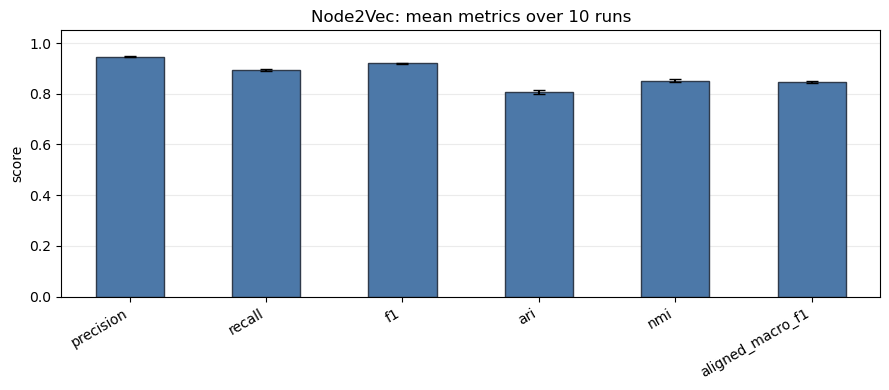

In [4]:
results = run_repeated_experiment(run_once, n_runs=N_RUNS, seed=SEED)
summary = summarize_metric_table(results)

display(results)
display(summary)
plot_metric_bars(summary, title=f'{METHOD_NAME}: mean metrics over {N_RUNS} runs')


## Assembly graph coloured by predicted bin

This plot reruns the method once on the original test graph using `SEED`, captures that method's KMeans bin assignments, and colours contigs in the igraph assembly graph by the predicted bin.

{'precision': 0.9469548133595285, 'recall': 0.8978388998035364, 'f1': 0.9217430238664633, 'ari': 0.813458078764732, 'nmi': 0.8537077590243944, 'n_bins_predicted': 5, 'n_true_bins': 5, 'aligned_macro_f1': 0.8481260557580255}
Node2Vec: assembly graph coloured by predicted bin
bin 0: 68 contigs
bin 1: 115 contigs
bin 2: 103 contigs
bin 3: 151 contigs
bin 4: 72 contigs


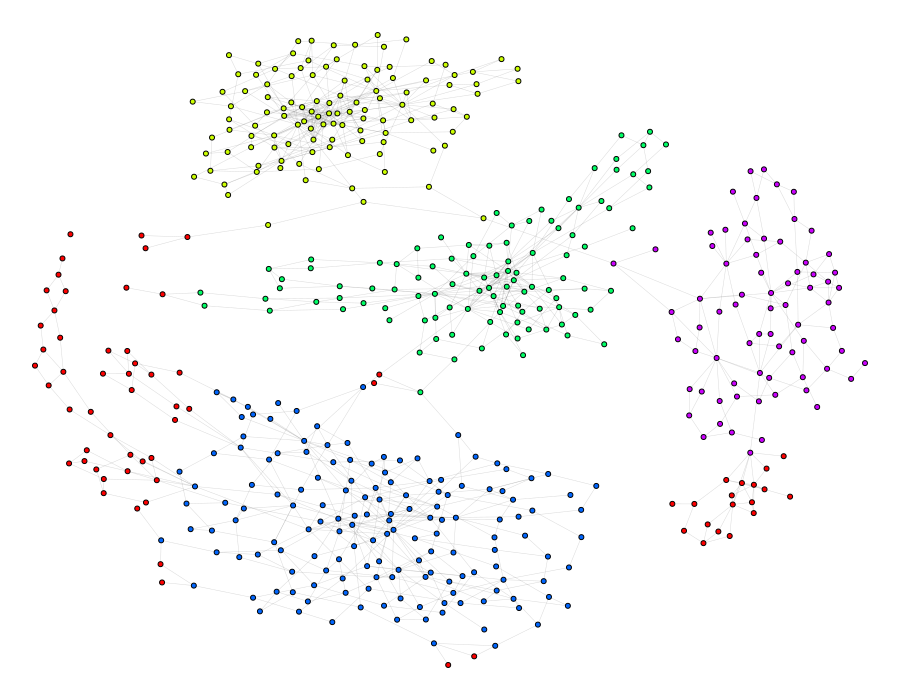

In [5]:
_visual_predictions = None
_original_run_kmeans = run_kmeans

def _capture_run_kmeans(embeddings, labels, seed=7, n_clusters=None):
    global _visual_predictions
    predictions, metrics = _original_run_kmeans(embeddings, labels, seed=seed, n_clusters=n_clusters)
    _visual_predictions = predictions
    return predictions, metrics

run_kmeans = _capture_run_kmeans
try:
    visual_metrics = run_once(SEED)
finally:
    run_kmeans = _original_run_kmeans

print(visual_metrics)
plot_assembly_graph_bins(
    data,
    bins=_visual_predictions,
    title=f'{METHOD_NAME}: assembly graph coloured by predicted bin',
)


## Graph corruption / ablation study

This section reruns the same method under five graph conditions: original assembly graph, random edge removal, random edge addition, coverage-similarity edges added, and short contigs removed. Each condition is run with the same 10 seeds, then metrics are summarized and plotted with standard-deviation error bars.

ablation: original assembly graph
ablation: random edge removal
ablation: random edge addition
ablation: coverage-similarity edges added
ablation: short contigs removed


,ablation,run,seed,precision,recall,f1,ari,nmi,n_bins_predicted,n_true_bins,aligned_macro_f1
0,original assembly graph,1,7,0.946955,0.897839,0.921743,0.813458,0.853708,5,5,0.848126
1,original assembly graph,2,8,0.944990,0.891945,0.917702,0.802235,0.845890,5,5,0.843356
2,original assembly graph,3,9,0.946955,0.893910,0.919668,0.806141,0.850536,5,5,0.845141
3,original assembly graph,4,10,0.950884,0.901768,0.925675,0.822750,0.865946,5,5,0.851551
4,original assembly graph,5,11,0.946955,0.897839,0.921743,0.813458,0.853708,5,5,0.848126
5,original assembly graph,6,12,0.944990,0.893910,0.918740,0.805125,0.846895,5,5,0.844936
6,original assembly graph,7,13,0.944990,0.888016,0.915617,0.796581,0.843949,5,5,0.840244
7,original assembly graph,8,14,0.944990,0.891945,0.917702,0.802235,0.845890,5,5,0.843356
8,original assembly graph,9,15,0.944990,0.899804,0.921843,0.814043,0.850053,5,5,0.849784
9,original assembly graph,10,16,0.948919,0.889980,0.918505,0.803103,0.853435,5,5,0.842049


precision                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.944990  0.950884  0.946562  0.002029   
random edge removal              0.921415  0.923379  0.922004  0.000949   
random edge addition             0.852652  0.907662  0.883890  0.022236   
coverage-similarity edges added  0.803536  0.838900  0.826523  0.010882   
short contigs removed            0.937778  0.942222  0.939556  0.001753   

                                   recall                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.888016  0.901768  0.894695  0.004461   
random edge removal              0.811395  0.836935  0.821415  0.008203   
random edge addition             0.803536  0.836935  0.820039  0.011904   
coverage-similarity edges added  0.762279  0.836935  0.811788  0.024934   
short contigs removed            0.831111  0.837778  0.834889  0.002354   

                                       f1            ...       ari            \
                                      min       max  ...      mean       std   
ablation                                             ...                       
original assembly graph          0.915617  0.925675  ...  0.807913  0.007790   
random edge removal              0.862912  0.878035  ...  0.703421  0.009479   
random edge addition             0.835111  0.865517  ...  0.644504  0.023732   
coverage-similarity edges added  0.788826  0.837916  ...  0.604182  0.029085   
short contigs removed            0.881228  0.886936  ...  0.743545  0.004343   

                                      nmi                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.843949  0.865946  0.851001  0.006359   
random edge removal              0.777866  0.789704  0.782065  0.003851   
random edge addition             0.660377  0.735616  0.697894  0.027008   
coverage-similarity edges added  0.593133  0.664699  0.635752  0.020351   
short contigs removed            0.815131  0.829824  0.821244  0.005700   

                                aligned_macro_f1                                
                                             min       max      mean       std  
ablation                                                                        
original assembly graph                 0.840244  0.851551  0.845667  0.003616  
random edge removal                     0.782157  0.798188  0.788392  0.005140  
random edge addition                    0.767239  0.799094  0.782533  0.010900  
coverage-similarity edges added         0.642418  0.804045  0.748646  0.062825  
short contigs removed                   0.796158  0.801681  0.799181  0.001956  

[5 rows x 24 columns]

<Axes: title={'center': 'Node2Vec: graph corruption / ablation study'}, xlabel='ablation', ylabel='score'>

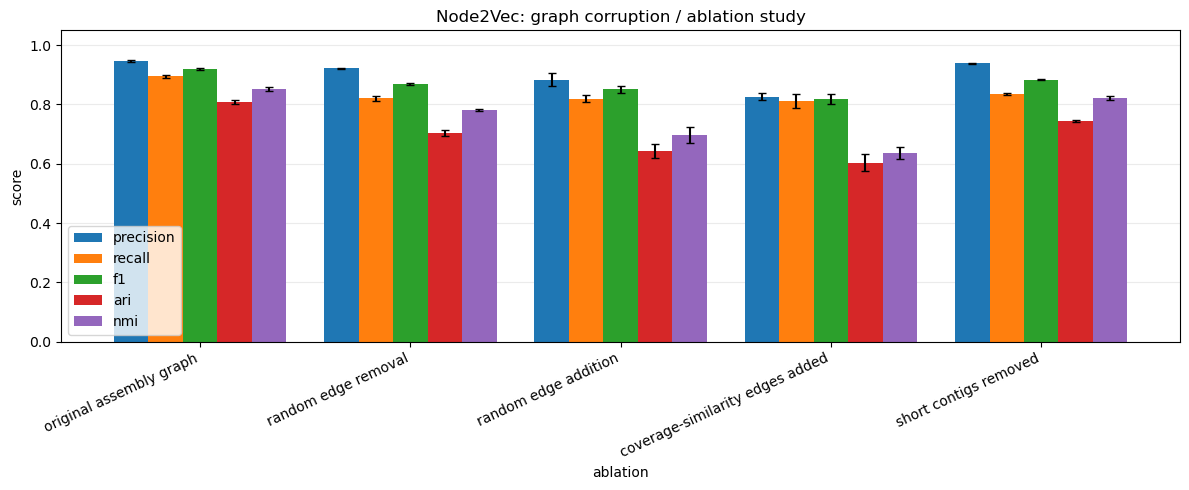

In [6]:
def run_once_ablation(seed, ablation_data):
    global features, adjacency, marker_pairs, labels, label_names, N_CLUSTERS, spectral_embeddings

    old_state = {
        'features': features,
        'adjacency': adjacency,
        'marker_pairs': marker_pairs,
        'labels': labels,
        'label_names': label_names,
        'N_CLUSTERS': N_CLUSTERS,
        'spectral_embeddings': globals().get('spectral_embeddings', None),
    }
    try:
        features = ablation_data['features']
        adjacency = ablation_data['adjacency']
        marker_pairs = ablation_data['marker_pairs']
        labels = ablation_data['labels']
        label_names = ablation_data['label_names']
        N_CLUSTERS = ablation_data['marker_cluster_count']

        # The Laplacian Eigenmaps notebook precomputes graph embeddings outside
        # run_once, so recompute them when the graph changes.
        if 'laplacian_eigenmap_embeddings' in globals():
            spectral_embeddings = laplacian_eigenmap_embeddings(adjacency, dimensions=32)

        return run_once(seed)
    finally:
        features = old_state['features']
        adjacency = old_state['adjacency']
        marker_pairs = old_state['marker_pairs']
        labels = old_state['labels']
        label_names = old_state['label_names']
        N_CLUSTERS = old_state['N_CLUSTERS']
        if old_state['spectral_embeddings'] is not None:
            spectral_embeddings = old_state['spectral_embeddings']

ablation_results, ablation_summary = run_graph_ablation_study(
    data,
    run_once_ablation,
    n_runs=N_RUNS,
    seed=SEED,
)

display(ablation_results)
display(ablation_summary)
plot_ablation_metric_bars(ablation_summary, title=f'{METHOD_NAME}: graph corruption / ablation study')
